In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import math
import pandas as pd
import os
from os import path
from tqdm import tqdm
import json
import cv2
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import datetime
import time
import random
from PIL import Image
import pickle
import joblib
import re

from sklearn import preprocessing
import tensorflow as tf
from keras.layers import Input,Dense,LSTM,Flatten,Dropout,concatenate,Conv1D,MaxPooling2D,Activation
from keras.layers import BatchNormalization
from keras.layers import Embedding
from tensorflow.keras import initializers, regularizers
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow import keras
import tensorflow_hub as hub
from tensorflow.keras.preprocessing import image, text, sequence
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint
import numpy as np

import warnings
warnings.filterwarnings("ignore")

## STAGE 2 - Split Train dataset into X_train and X_val  
### Use Validation dataset (with class labels) as X_test to check accuracy

In [ ]:
train_df_k1000 = pd.read_csv("/content/drive/MyDrive/VQA_Dataset/abstract_train2015_preprocessed_k999_other.csv")
X = train_df_k1000[['image_id','question_preprocessed', 'answers']]
y = train_df_k1000['class_label']

In [ ]:
print(train_df_k1000.shape)
print(X.shape, y.shape)

In [ ]:
val_df_k1000 = pd.read_csv("/content/drive/MyDrive/VQA_Dataset/abstract_val2015_preprocessed_k999_other.csv")
X_val_test = val_df_k1000[['image_id','question_preprocessed', 'answers']]
y_val_test = val_df_k1000['class_label']

In [ ]:
print(val_df_k1000.shape)
print(X_val_test.shape, y_val_test.shape)

In [ ]:
from sklearn.model_selection import train_test_split
import pickle
from tensorflow.keras.utils import to_categorical

# Splitting into train (80%), validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y,  random_state=42)
# Use the given validation set as test set
X_test, y_test = X_val_test, y_val_test

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

# Convert labels to categorical (before passing it to neural network model)
Y_train = to_categorical(y_train, 1000)
Y_val = to_categorical(y_val, 1000)
Y_test = to_categorical(y_test, 1000)

# STAGE 3.1 - Process TRAIN and VALIDATION set for Model training

In [ ]:
# Initialize tokenizer (no default filters)
t = Tokenizer(filters='')

# Fit ONLY on training set
t.fit_on_texts(list(X_train['question_preprocessed']))  # Vocabulary built from training data only
vocab_size = len(t.word_index) + 1  # Define vocab size

# Stage 6. Predict labels for 1 pkl file in Validation Set (used as Test set)

In [ ]:
# Load test data (first 1000 preprocessed)
test_data_path = "/content/drive/MyDrive/VQA_Dataset/test_data/processed_test_data_part_2000.pkl"
test_data = pickle.load(open(test_data_path, "rb"))
# Extract components from the dictionary
test_images = test_data["test_images"]
test_questions = test_data["test_questions"]
test_labels = test_data["test_labels"]  # These are one-hot encoded

In [ ]:
# Print shapes to confirm data integrity
print(f"Test Images Shape: {test_images.shape}")
print(f"Test Questions Shape: {test_questions.shape}")
print(f"Test Labels Shape: {test_labels.shape}")

Test Images Shape: (1000, 224, 224, 3)
Test Questions Shape: (1000, 22)
Test Labels Shape: (1000, 1000)


In [ ]:
# Get true labels (first 1000 from original y_test)
# If one-hot encoded: convert back
true_class = np.argmax(test_labels, axis=1)
true_class.shape

(1000,)

# Load Model for test

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/VQA_Dataset/final_model/full_model_new_24.keras')


# Predict with model
predicted_probs = model.predict([test_images, test_questions], verbose=0)
predicted_class = np.argmax(predicted_probs, axis=1)

In [ ]:
predicted_class.shape

(1000,)

##  Accuracy check using exact label matches

In [ ]:
# Compare exact match
accuracy = np.mean(predicted_class == true_class)
print(f"Accuracy on first 1000 test samples: {accuracy * 100:.2f}%")

Accuracy on first 1000 test samples: 28.20%


In [ ]:
labelencoder = pickle.load(open("/content/drive/MyDrive/VQA_Dataset/labelencoder2.pkl", "rb"))
decoded_preds = labelencoder.inverse_transform(predicted_class)
decoded_true = labelencoder.inverse_transform(true_class)

In [ ]:
decoded_true[:50]

array(['no bird', 'yes', '2', 'no bird', '18', '3', 'yes', 'pigtails',
       'tree', 'no bird', 'dog', 'sunset', '2', 'no one is home', 'yes',
       'no bird', 'sleeping', 'yes', 'brown', 'yellow', 'yes', 'yes',
       'yes', 'dancing', 'yes', 'no bird', 'match', 'right', 'green',
       'yes', 'yes', 'skateboard', 'no bird', 'in pond', 'purple', 'yes',
       'yes', 'yes', 'gold', '2', 'right', 'yes', 'yes', 'painting', '3',
       'no bird', 'no bird', 'no bird', 'pine', 'yes'], dtype='<U26')

In [ ]:
decoded_preds[:50]

array(['yes', 'no', '2', 'no', '2', '2', 'yes', 'soccer ball', 'dog',
       'yes', 'food', 'other', '2', 'yes', 'no', 'no', 'sleeping', 'yes',
       'white', 'white', 'no', 'yes', 'no', 'sitting', 'no', 'other',
       'marshmallow', 'left', 'white', 'yes', 'yes', 'other', 'yes',
       'park', 'white', 'yes', 'no', 'no', 'brown', '2', 'yes', 'yes',
       'no', 'plant', '2', 'yes', 'no', 'no', 'rocks', 'yes'],
      dtype='<U26')

## Accuracy check according to orignal research paper

In [ ]:
#  Research Paper Link: https://arxiv.org/pdf/1505.00468.pdf
labelencoder = pickle.load(open('/content/drive/MyDrive/VQA_Dataset/labelencoder2.pkl', 'rb'))

def accuracy_metric(X,Y,encoded_features,model):

  predicted_Y = model.predict(encoded_features,verbose=0)
  predicted_class = tf.argmax(predicted_Y, axis=1, output_type=tf.int32)
  predicted_ans = labelencoder.inverse_transform(predicted_class)

  acc_val_lst = []
  for i in tqdm(range(len(Y))):
    acc_val = 0.0
    temp = 0
    actual_answer_list = X['answers'].iloc[i]
    if isinstance(actual_answer_list, str):  # in case it's stored as a string
      actual_answer_list = actual_answer_list.strip("[]").replace("'", "").split(", ")

    for actual_ans in actual_answer_list:
      if actual_ans.strip() == predicted_ans[i]:
        temp += 1

    if temp >= 3:
      acc_val = 1
    else:
      acc_val = float(temp)/3

    acc_val_lst.append(acc_val)

  return (sum(acc_val_lst)/len(Y))*100

In [ ]:
# Slice the last 41 entries
X_test_subset = X_test[1000:2000].reset_index(drop=True)
y_test_subset = y_test[1000:2000].reset_index(drop=True)

In [ ]:
Test_accuracy = accuracy_metric(X_test_subset, y_test_subset, [test_images, test_questions], model)

100%|██████████| 1000/1000 [00:00<00:00, 60919.45it/s]


In [ ]:
print("\nTest accuracy of first 1000 Datapoints:",np.round(Test_accuracy,2))


Test accuracy of first 1000 Datapoints: 42.93


# Consider a sample question from test set and check true and predicted labels

In [ ]:
sample = X_test_subset.iloc[49]
sample

,49
image_id,/content/drive/MyDrive/VQA_Dataset/scene_img_a...
question_preprocessed,how many steps are on the sliding board
answers,"['6', '5', '5', '5', '5', '5', '5', '5', '5', ..."


In [ ]:
X_test_subset['image_id'].iloc[49]

'/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_val2015/abstract_v002_val2015_000000026002.png'

In [ ]:
true_label = y_test_subset.iloc[49]
# Get the original label (optional, for display)
true_answer = labelencoder.inverse_transform([true_label])[0]

In [ ]:
# --- Preprocess Image ---
img = cv2.imread(sample['image_id'])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img = img / 255.0

# Add batch dimension
img = np.expand_dims(img, axis=0)

In [ ]:
# --- Preprocess Question ---
question = sample['question_preprocessed']
que_vector = pad_sequences(t.texts_to_sequences([question]), maxlen=22, padding='post')

In [ ]:
# --- Predict ---
predicted_probs = model.predict([img, que_vector], verbose=0)
predicted_class = np.argmax(predicted_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([predicted_class])[0]

In [ ]:
# --- Display ---
print(f"True Label: {true_answer}")
print(f"Predicted: {predicted_answer}")

True Label: 5
Predicted: 5


# Load an image and ask a question

In [ ]:
import matplotlib.pyplot as plt
import cv2
img_path = "/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_val2015/abstract_v002_val2015_000000026002.png"
# Load and convert the image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load and preprocess image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img = img / 255.0  # Normalize
img = np.expand_dims(img, axis=0)  # Add batch dimension

In [ ]:
def decontractions(phrase):
    """decontracted takes text and convert contractions into natural form.
     ref: https://stackoverflow.com/questions/19790188/expanding-english-language-contractions-in-python/47091490#47091490"""
    # specific
    phrase = re.sub(r"won\'t", "will not", phrase)
    phrase = re.sub(r"can\'t", "can not", phrase)
    phrase = re.sub(r"won\’t", "will not", phrase)
    phrase = re.sub(r"can\’t", "can not", phrase)
    phrase = re.sub(r"he\'s", "he is", phrase)
    phrase = re.sub(r"she\'s", "she is", phrase)
    phrase = re.sub(r"it\'s", "it is", phrase)
    phrase = re.sub(r"he\’s", "he is", phrase)
    phrase = re.sub(r"she\’s", "she is", phrase)
    phrase = re.sub(r"it\’s", "it is", phrase)

    # general
    phrase = re.sub(r"n\'t", " not", phrase)
    phrase = re.sub(r"\'re", " are", phrase)
    phrase = re.sub(r"\'d", " would", phrase)
    phrase = re.sub(r"\'ll", " will", phrase)
    phrase = re.sub(r"\'t", " not", phrase)
    phrase = re.sub(r"\'ve", " have", phrase)
    phrase = re.sub(r"\'m", " am", phrase)

    phrase = re.sub(r"n\’t", " not", phrase)
    phrase = re.sub(r"\’re", " are", phrase)
    phrase = re.sub(r"\’d", " would", phrase)
    phrase = re.sub(r"\’ll", " will", phrase)
    phrase = re.sub(r"\’t", " not", phrase)
    phrase = re.sub(r"\’ve", " have", phrase)
    phrase = re.sub(r"\’m", " am", phrase)

    return phrase
def text_preprocess(text):
    text = text.lower()
    text = decontractions(text) # replace contractions into natural form
    text = re.sub('[-,:]', ' ', text) # replace the character "-" "," with space
    text = re.sub("(?!<=\d)(\.)(?!\d)", '', text) # remove the character ".", except from floating numbers
    text = re.sub('[^A-Za-z0-9. ]+', '', text) # remove all punctuation, except A-Za-z0-9
    text = re.sub(' +', ' ', text) # remove extra space
    return text

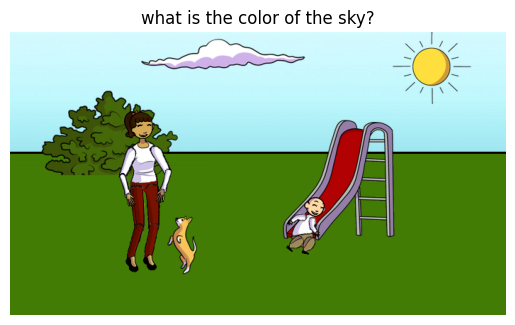

Predicted Answer: blue


In [ ]:
# Example question - not in dataset
question = "what is the color of the sky?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

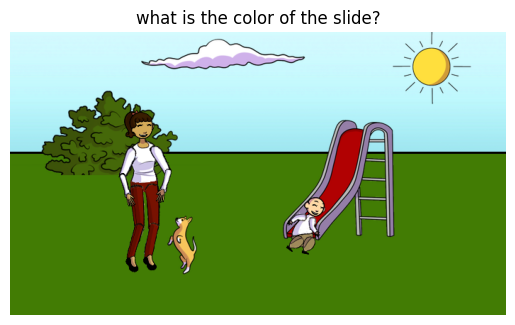

Predicted Answer: red


In [ ]:
# Example question - not in dataset
question = "what is the color of the slide?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

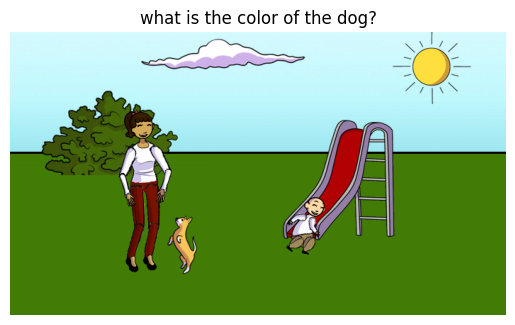

Predicted Answer: yellow


In [ ]:
# Example question - not in dataset
question = "what is the color of the dog?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

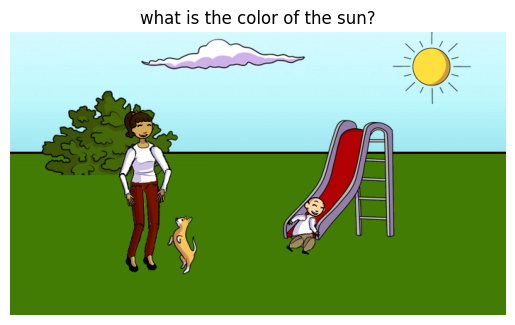

Predicted Answer: yellow


In [ ]:
# Example question - not in dataset
question = "what is the color of the sun?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

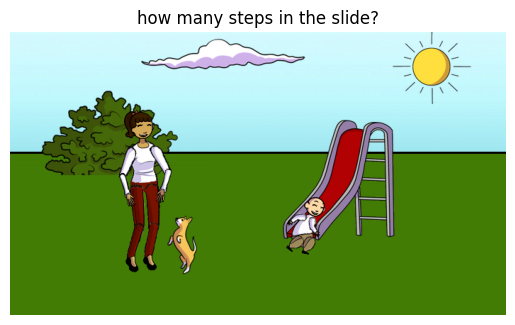

Predicted Answer: 5


In [ ]:
# Example question - not in dataset
question = "how many steps in the slide?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

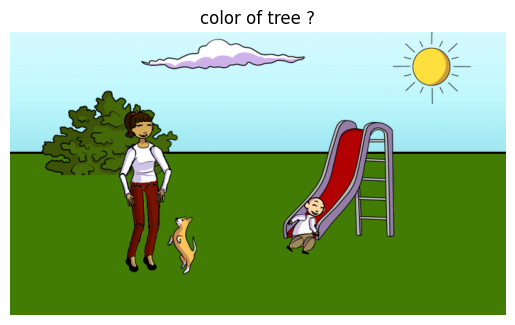

Predicted Answer: green


In [ ]:
# Example question - not in dataset
question = "color of tree ?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

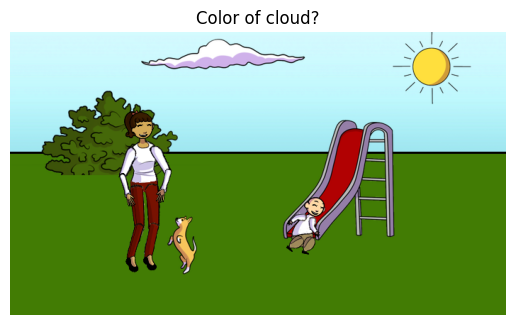

Predicted Answer: white


In [ ]:
# Example question - not in dataset
question = "Color of cloud?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

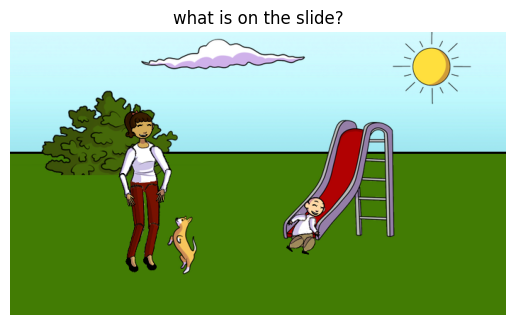

Predicted Answer: boy


In [ ]:
# Example question - not in dataset
question = "what is on the slide?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)


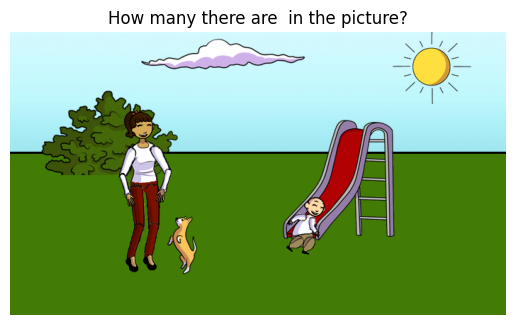

Predicted Answer: 2


In [ ]:
# Example question - not in dataset
question = "How many there are  in the picture?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)


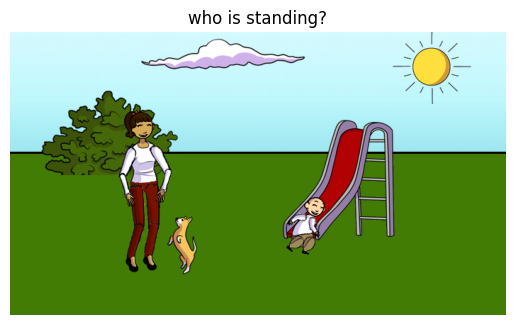

Predicted Answer: woman


In [ ]:
# Example question - not in dataset
question = "who is standing?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)


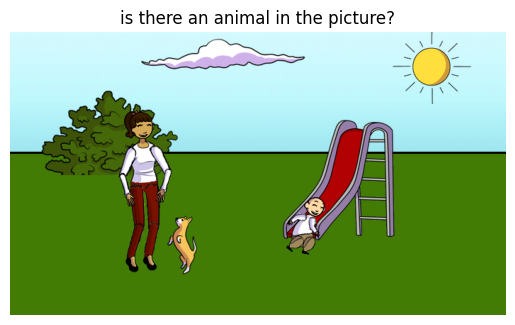

Predicted Answer: yes


In [ ]:
# Example question - not in dataset
question = "is there an animal in the picture?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)


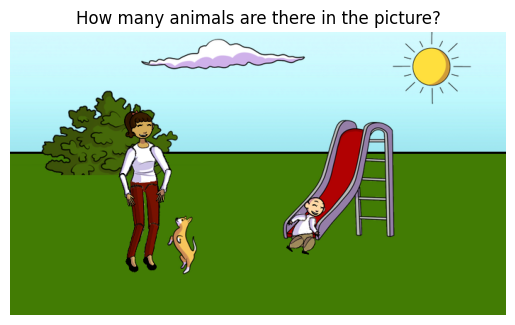

Predicted Answer: 2


In [ ]:
# Example question - not in dataset
question = "How many animals are there in the picture?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)


# Image from test set

In [ ]:
import matplotlib.pyplot as plt
import cv2
img_path = "/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_test2015/abstract_v002_test2015_000000030033.png"
# Load and convert the image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load and preprocess image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img = img / 255.0  # Normalize
img = np.expand_dims(img, axis=0)  # Add batch dimension

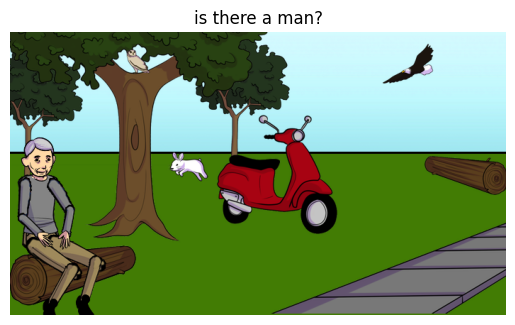

Predicted Answer: yes


In [ ]:
# Example question - not in dataset
question = "is there a man?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)


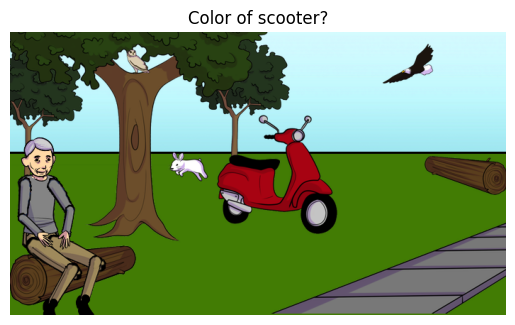

Predicted Answer: red


In [ ]:
# Example question - not in dataset
question = "Color of scooter?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

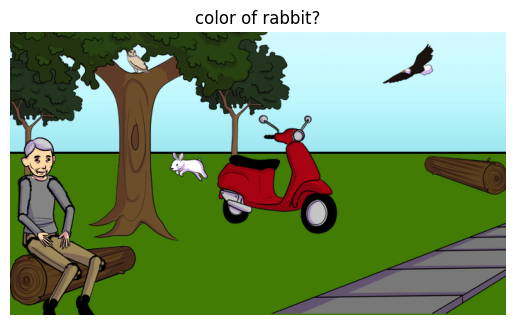

Predicted Answer: white


In [ ]:
# Example question - not in dataset
question = "color of rabbit?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

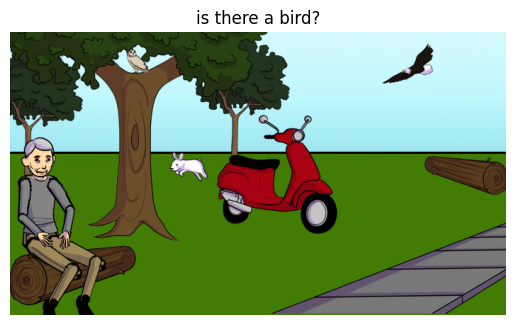

Predicted Answer: yes


In [ ]:
# Example question - not in dataset
question = "is there a bird?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

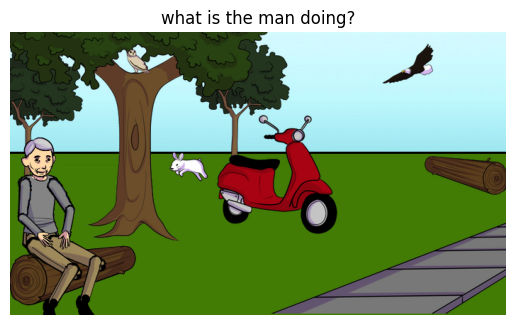

Predicted Answer: sitting


In [ ]:
# Example question - not in dataset
question = "what is the man doing?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

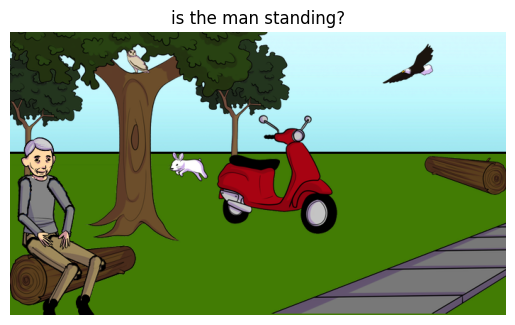

Predicted Answer: no


In [ ]:
# Example question - not in dataset
question = "is the man standing?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

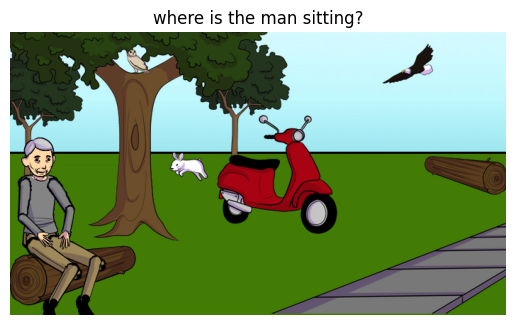

Predicted Answer: bench


In [ ]:
# Example question - not in dataset
question = "where is the man sitting?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

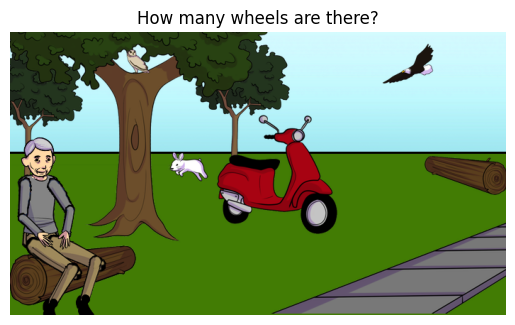

Predicted Answer: 2


In [ ]:
# Example question - not in dataset
question = "How many wheels are there?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

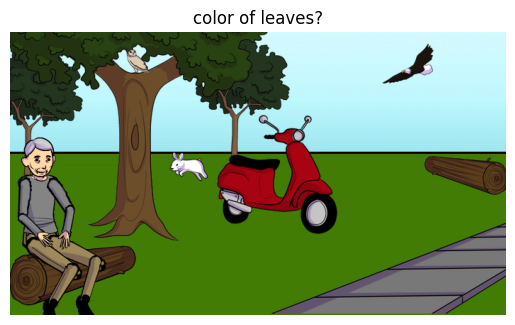

Predicted Answer: green


In [ ]:
# Example question - not in dataset
question = "color of leaves?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

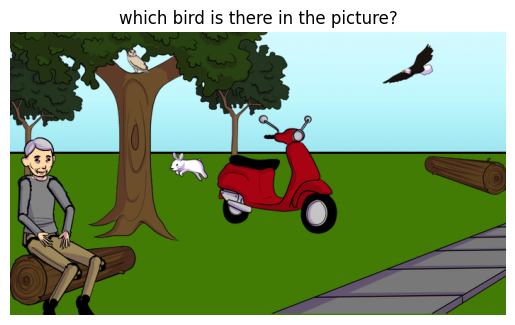

Predicted Answer: eagle


In [ ]:
# Example question - not in dataset
question = "which bird is there in the picture?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

In [ ]:
import matplotlib.pyplot as plt
import cv2
img_path = "/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_test2015/abstract_v002_test2015_000000049131.png"
# Load and convert the image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load and preprocess image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img = img / 255.0  # Normalize
img = np.expand_dims(img, axis=0)  # Add batch dimension

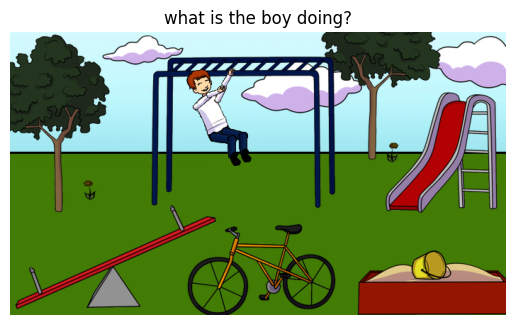

Predicted Answer: playing


In [ ]:
# Example question - not in dataset
question = "what is the boy doing?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

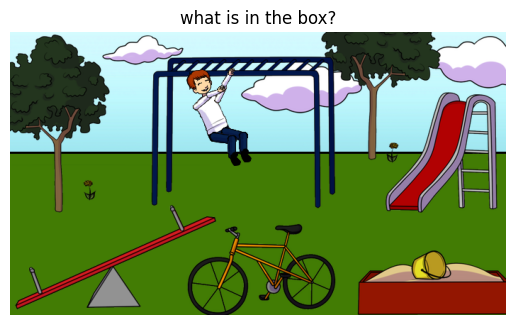

Predicted Answer: sand


In [ ]:
# Example question - not in dataset
question = "what is in the box?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

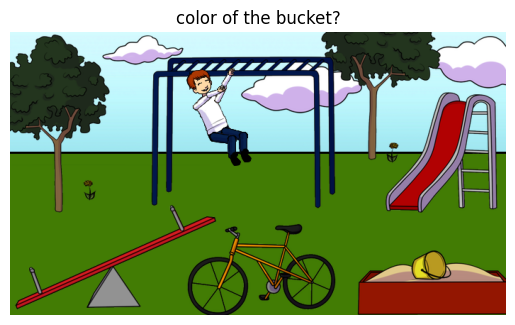

Predicted Answer: yellow


In [ ]:
# Example question - not in dataset
question = "color of the bucket?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

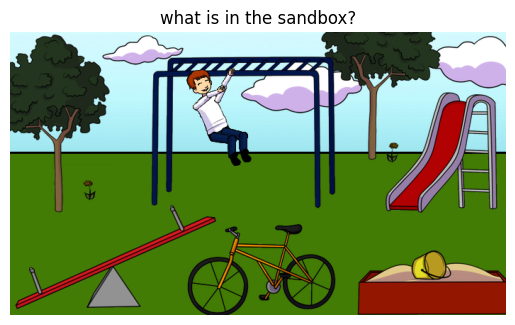

Predicted Answer: sand


In [ ]:
# Example question - not in dataset
question = "what is in the sandbox?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

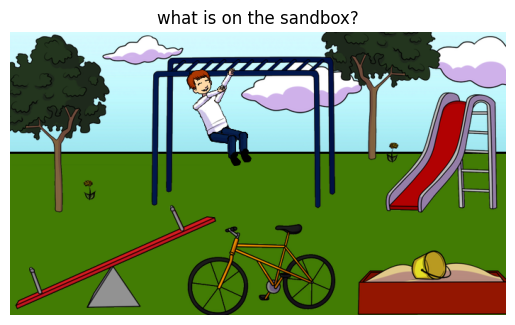

Predicted Answer: shovel


In [ ]:
# Example question - not in dataset
question = "what is on the sandbox?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

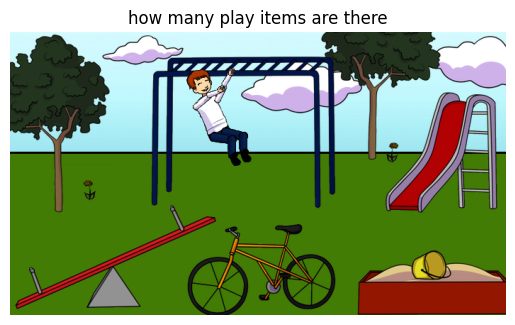

Predicted Answer: 2


In [ ]:
# Example question - not in dataset
question = "how many play items are there"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

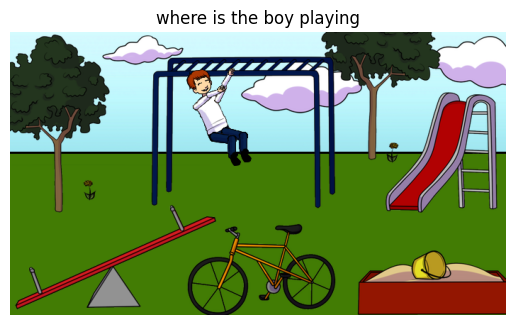

Predicted Answer: sandbox


In [ ]:
# Example question - not in dataset
question = "where is the boy playing"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

In [ ]:
import matplotlib.pyplot as plt
import cv2
img_path = "/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_test2015/abstract_v002_test2015_000000049119.png"
# Load and convert the image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load and preprocess image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img = img / 255.0  # Normalize
img = np.expand_dims(img, axis=0)  # Add batch dimension

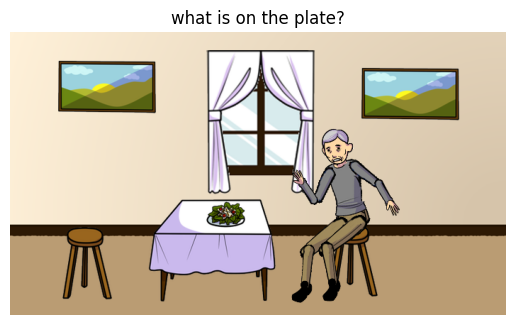

Predicted Answer: food


In [ ]:
# Example question - not in dataset
question = "what is on the plate?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

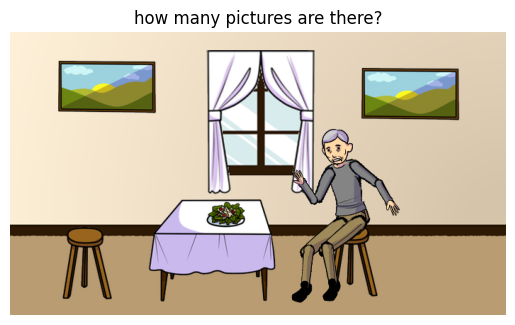

Predicted Answer: 2


In [ ]:
# Example question - not in dataset
question = "how many pictures are there?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

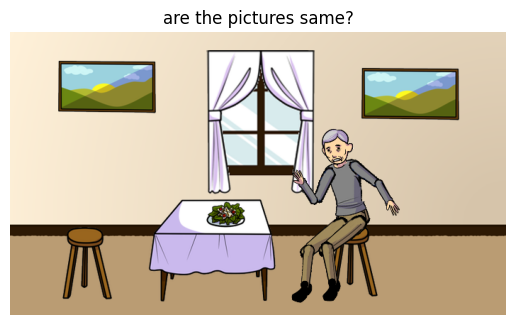

Predicted Answer: yes


In [ ]:
# Example question - not in dataset
question = "are the pictures same?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

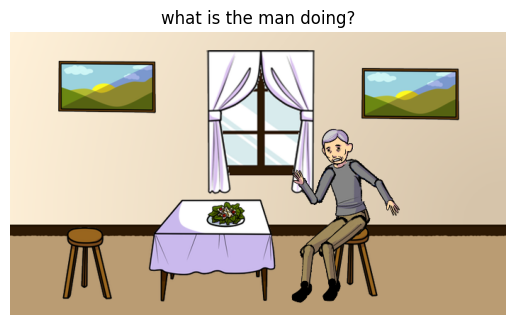

Predicted Answer: sitting


In [ ]:
# Example question - not in dataset
question = "what is the man doing?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

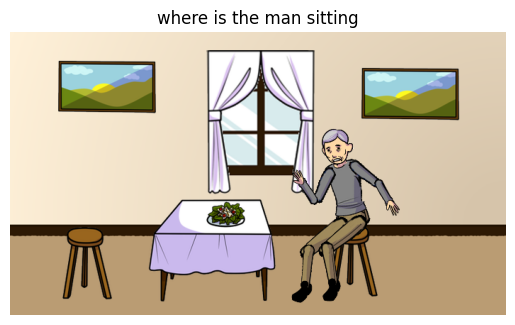

Predicted Answer: couch


In [ ]:
# Example question - not in dataset
question = "where is the man sitting"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

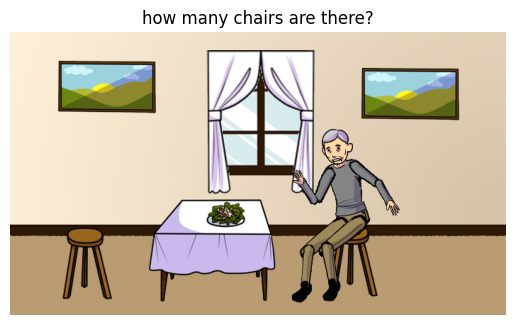

Predicted Answer: 2


In [ ]:
# Example question - not in dataset
question = "how many chairs are there?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

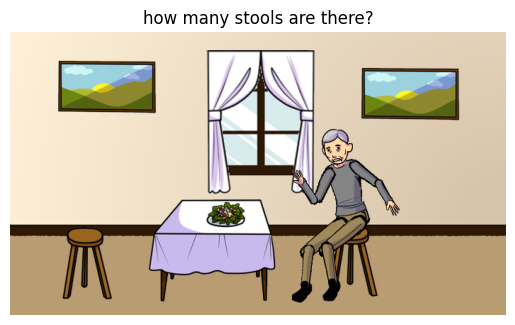

Predicted Answer: 2


In [ ]:
# Example question - not in dataset
question = "how many stools are there?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

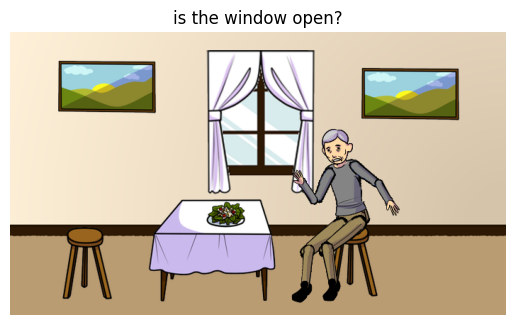

Predicted Answer: no


In [ ]:
# Example question - not in dataset
question = "is the window open?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

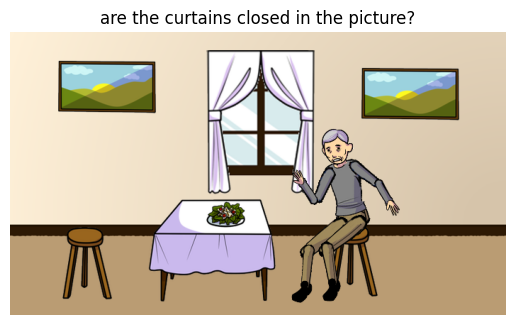

Predicted Answer: yes


In [ ]:
# Example question - not in dataset
question = "are the curtains closed in the picture?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

In [ ]:
import matplotlib.pyplot as plt
import cv2
img_path = "/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_test2015/abstract_v002_test2015_000000030080.png"
# Load and convert the image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load and preprocess image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img = img / 255.0  # Normalize
img = np.expand_dims(img, axis=0)  # Add batch dimension

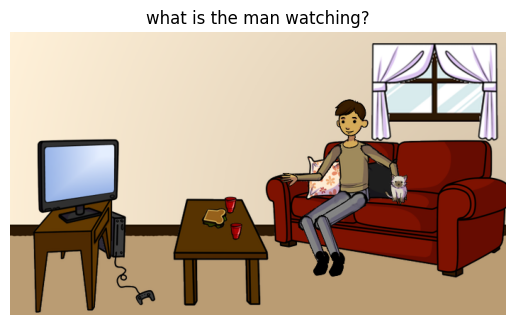

Predicted Answer: tv


In [ ]:
# Example question - not in dataset
question = "what is the man watching?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

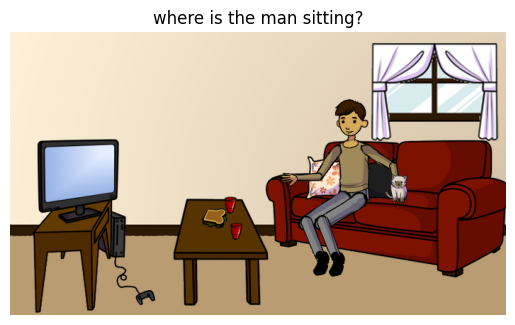

Predicted Answer: couch


In [ ]:
# Example question - not in dataset
question = "where is the man sitting?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

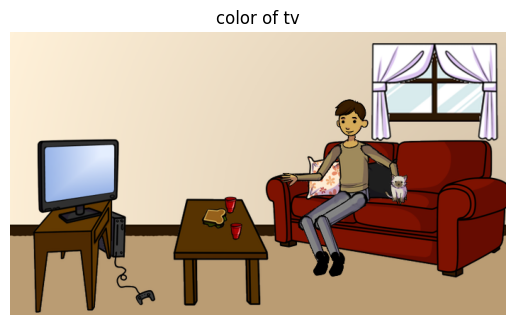

Predicted Answer: black


In [ ]:
# Example question - not in dataset
question = "color of tv"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

In [ ]:
import matplotlib.pyplot as plt
import cv2
img_path = "/content/drive/MyDrive/VQA_Dataset/scene_img_abstract_v002_test2015/abstract_v002_test2015_000000030110.png"
# Load and convert the image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load and preprocess image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img = img / 255.0  # Normalize
img = np.expand_dims(img, axis=0)  # Add batch dimension

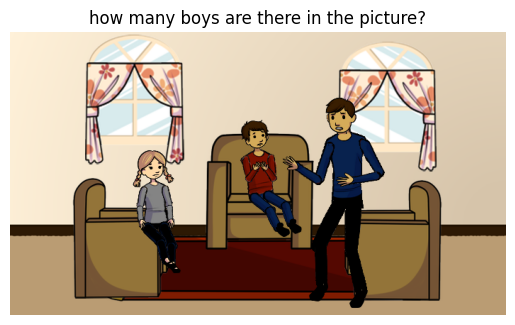

Predicted Answer: 2


In [ ]:
# Example question - not in dataset
question = "how many boys are there in the picture?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

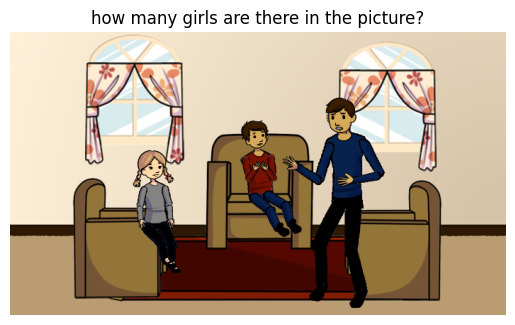

Predicted Answer: 2


In [ ]:
# Example question - not in dataset
question = "how many girls are there in the picture?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

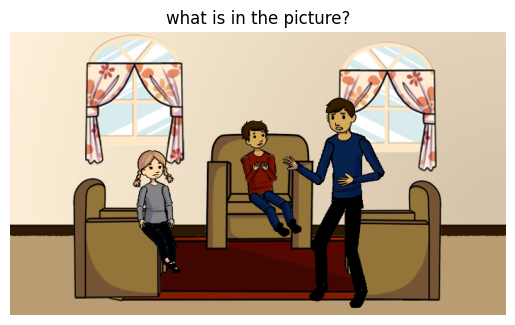

Predicted Answer: sunset


In [ ]:
# Example question - not in dataset
question = "what is in the picture?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

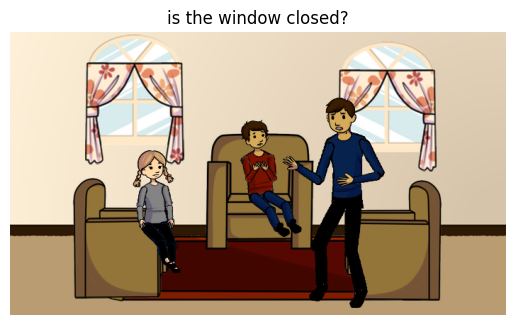

Predicted Answer: yes


In [ ]:
# Example question - not in dataset
question = "is the window closed?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

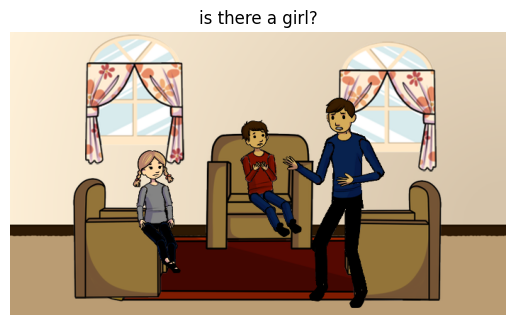

Predicted Answer: yes


In [ ]:
# Example question - not in dataset
question = "is there a girl?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)

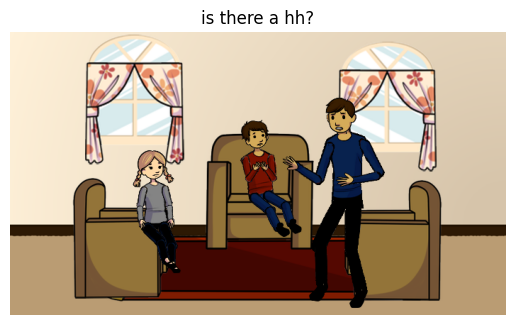

Predicted Answer: yes


In [ ]:
# Example question - not in dataset
question = "is there a hh?"
question_preprocessed = text_preprocess(question)
question_seq = pad_sequences(t.texts_to_sequences([question_preprocessed]), maxlen=22, padding='post')
pred_probs = model.predict([img, question_seq], verbose=0)
pred_class = np.argmax(pred_probs, axis=1)[0]
predicted_answer = labelencoder.inverse_transform([pred_class])[0]
plt.imshow(img_rgb)
plt.axis('off')
plt.title(question)
plt.show()
print("Predicted Answer:", predicted_answer)